# Notebook 1.2b - Annual Dispatch Reducer Prototype

This notebook is a prototype for rearchitecting Strategy 2 from Notebook 1.2.

**Goal:**
- Replace sampled weeks with a **month-by-month reducer** over the full 2025 year.
- Keep memory bounded by reducing each month immediately rather than concatenating raw annual 5-minute dispatch.
- Preserve the same core data source: `DISPATCHLOAD.INITIALMW` plus the AEMO registration workbook.

**Required data prep:**
```bash
uv run python import_nem_data.py --start 2025/01/01 --end 2025/12/31 --dispatchload --dudetailsummary
uv run python -c "
from nemosis import cache_compiler
cache_compiler('2025/01/01 00:00:00', '2025/12/31 23:55:00',
               'DUDETAIL', './data/nemosis_cache', fformat='parquet')
"
```
Save `NEM Registration and Exemption List.xlsx` into `./data/nemosis_cache/`.

**Setup note:**
- This notebook assumes the cache already exists and does not revalidate downloads inside the notebook.
- `import_nem_data.py` does **not** expose a `--dudetail` flag, so `DUDETAIL` must be cached directly with NEMOSIS.

**DUID metadata strategy:**

`DISPATCHLOAD` is a raw operational log — it has DUID and INITIALMW but no region, fuel type, or capacity.
Three separate AEMO sources provide the metadata needed to make dispatch data meaningful:

| Source | Provides | Limitation |
|--------|----------|------------|
| **Registration workbook** (Excel) | Fuel type, region, capacity, station name | Point-in-time snapshot of *currently* registered units. Deregistered, commissioning, or testing units may be absent. Manually maintained. |
| **DUDETAILSUMMARY** (MMS table) | REGIONID, connection point, date ranges | Machine-generated by the dispatch engine — comprehensive DUID coverage including historical. **No fuel type.** |
| **DUDETAIL** (MMS table) | Registered capacity, versioned by effective date | Same comprehensive coverage as DUDETAILSUMMARY. **No fuel type, no region.** |

Fuel type classification is an administrative/reporting concern that only exists in the registration workbook —
the dispatch engine doesn't care what fuel a unit burns, it just clears MW at a price. This means the
workbook must be the primary metadata source. `DUDETAIL` and `DUDETAILSUMMARY` are used as backfill
for DUIDs that appear in dispatch but are missing from the workbook, tagged as fuel type "Other" since
we genuinely don't know. This prevents real dispatched MWh from silently vanishing from regional totals.

**Reducer design:**
- Load one month of `DISPATCHLOAD` at a time.
- Filter `INTERVENTION == 0` and shift to interval-start timestamps.
- Join workbook metadata plus `DUDETAIL` and `DUDETAILSUMMARY` backfill for DUID coverage.
- Reduce immediately to `unit_day`, `unit_month`, and `region_fuel_month`.
- Derive `annual_unit` from the monthly reducer outputs.

**Output choices:**
- Keep `INITIALMW` as the source dispatch measure for comparability with Notebook 1.2.
- Clip negative dispatch to zero when aggregating generation MWh so battery charging does not subtract from generation-mix visuals.
- Do not retain raw annual interval data in memory.


In [22]:
import calendar
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

YEAR = 2025
YEAR_MONTHS = [f'{YEAR}{month:02d}' for month in range(1, 13)]
CACHE = Path('../data/nemosis_cache')

# --- File discovery ---
dispatchload_by_month = {
    f.stem.split('#')[3][:6]: f
    for f in sorted(CACHE.glob('*DISPATCHLOAD*.parquet'))
}
dudetail_files = sorted(CACHE.glob('*DUDETAIL#FILE01#*.parquet'))
dudetailsummary_files = sorted(CACHE.glob('*DUDETAILSUMMARY*.parquet'))

# --- Registration workbook ---
registration = (
    pl.from_pandas(
        pd.read_excel(
            CACHE / 'NEM Registration and Exemption List.xlsx',
            sheet_name='PU and Scheduled Loads',
            engine='openpyxl',
        )
        .assign(
            FUEL_SOURCE_PRIMARY=lambda df: df['Fuel Source - Descriptor'].fillna(df['Fuel Source - Primary']),
            REG_CAPACITY=lambda df: pd.to_numeric(df['Reg Cap generation (MW)'], errors='coerce'),
            REGIONID=lambda df: df['Region'],
            STATIONNAME=lambda df: df['Station Name'],
        )
        [['DUID', 'FUEL_SOURCE_PRIMARY', 'REG_CAPACITY', 'REGIONID', 'STATIONNAME']]
    )
    .unique(subset=['DUID'], keep='last')
    .with_columns(pl.col('FUEL_SOURCE_PRIMARY').str.strip_chars())
)

fuel_map = {
    'Brown Coal': 'Coal', 'Black Coal': 'Coal',
    'Coal Seam Methane': 'Coal', 'Waste Coal Mine Gas': 'Coal',
    'Natural Gas': 'Gas', 'Natural Gas / Fuel Oil': 'Gas',
    'Natural Gas / Diesel': 'Gas', 'Natrual Gas/ Diesel': 'Gas',
    'Diesel': 'Gas', 'Kerosene': 'Gas', 'Ethane': 'Gas',
    'Wind': 'Wind', 'Solar': 'Solar',
    'Water': 'Hydro', 'Hydro': 'Hydro',
    'Grid': 'Battery', 'Battery': 'Battery',
    'Battery Storage': 'Battery', 'Battery / Solar': 'Battery',
    'Biomass': 'Biomass', 'Bagasse': 'Biomass', 'Bagasse and Diesel': 'Biomass',
    'Landfill Methane / Landfill Gas': 'Biomass',
    'Biogas - sludge': 'Biomass', 'Sewerage / Waste Water': 'Biomass',
    'Renewable/ Biomass / Waste': 'Biomass',
    'Renewable/ Biomass / Waste and Fossil': 'Biomass',
}

registration = registration.with_columns(
    pl.col('FUEL_SOURCE_PRIMARY')
    .replace_strict(fuel_map, default='Other')
    .alias('FUEL_TYPE')
)

# --- DUDETAIL/DUDETAILSUMMARY backfill for DUIDs missing from the workbook ---
# DUDETAILSUMMARY provides REGIONID; DUDETAIL provides registered capacity.
# Backfill DUIDs are tagged as fuel type "Other" since no MMS table carries fuel info.
workbook_duids = registration['DUID'].to_list()

dudetailsummary = (
    pl.concat([pl.read_parquet(f) for f in dudetailsummary_files], how='vertical_relaxed')
    .sort('DUID', 'START_DATE', descending=[False, True])
    .unique(subset=['DUID'], keep='first')
    .filter(~pl.col('DUID').is_in(workbook_duids))
    .select(['DUID', 'REGIONID'])
)

dudetail = (
    pl.concat([pl.read_parquet(f) for f in dudetail_files], how='vertical_relaxed')
    .sort('DUID', 'EFFECTIVEDATE', 'VERSIONNO', descending=[False, True, True])
    .unique(subset=['DUID'], keep='first')
    .select(['DUID', pl.col('REGISTEREDCAPACITY').alias('REG_CAPACITY')])
)

backfill = (
    dudetailsummary
    .join(dudetail, on='DUID', how='left')
    .with_columns(
        pl.lit('Other').alias('FUEL_TYPE'),
        pl.lit(None, dtype=pl.String).alias('FUEL_SOURCE_PRIMARY'),
        pl.lit(None, dtype=pl.String).alias('STATIONNAME'),
    )
    .select(registration.columns)
)

unit_meta = pl.concat([registration, backfill], how='vertical_relaxed')

# --- Dispatch column casts ---
DISPATCH_CASTS = [
    pl.col('SETTLEMENTDATE').str.strptime(pl.Datetime, '%Y/%m/%d %H:%M:%S'),
    pl.col('INITIALMW').cast(pl.Float64),
    pl.col('INTERVENTION').cast(pl.Int32),
]

# --- Visualisation constants ---
stack_order = ['Coal', 'Hydro', 'Wind', 'Solar', 'Gas', 'Battery', 'Biomass', 'Other']
stack_colors = {
    'Coal': '#4A4A4A', 'Gas': '#FF6B6B', 'Hydro': '#4ECDC4',
    'Wind': '#95E1D3', 'Solar': '#FFD93D', 'Battery': '#9D65C9',
    'Biomass': '#6BCB77', 'Other': '#B8B8B8',
}
region_order = ['NSW1', 'VIC1', 'QLD1', 'SA1', 'TAS1']
month_labels = [calendar.month_abbr[m] for m in range(1, 13)]

def present_stack_fuels(frame):
    return [fuel for fuel in stack_order if fuel in frame.columns]

# --- Month reducer ---
def reduce_month(month_key):
    """Load one month of DISPATCHLOAD, enrich with metadata, reduce to summaries."""
    month_file = dispatchload_by_month[month_key]
    month_num = int(month_key[4:6])
    days_in_month = calendar.monthrange(int(month_key[:4]), month_num)[1]

    dispatch = (
        pl.scan_parquet([month_file])
        .with_columns(DISPATCH_CASTS)
        .filter(pl.col('INTERVENTION') == 0)
        .select(
            (pl.col('SETTLEMENTDATE') - pl.duration(minutes=5)).alias('SETTLEMENTDATE'),
            'DUID',
            pl.col('INITIALMW').alias('DISPATCH_MW'),
        )
        .collect()
    )

    enriched = dispatch.join(
        unit_meta.select('DUID', 'FUEL_TYPE', 'REG_CAPACITY', 'REGIONID', 'STATIONNAME'),
        on='DUID', how='left',
    )
    missing = enriched.filter(pl.col('REGIONID').is_null()).select('DUID').unique()
    enriched = (
        enriched
        .filter(pl.col('REGIONID').is_not_null())
        .with_columns(pl.col('SETTLEMENTDATE').dt.date().alias('DAY'))
    )

    # unit_day: per-DUID per-day
    ud = (
        enriched.group_by('DUID', 'DAY')
        .agg(
            (pl.col('DISPATCH_MW').clip(lower_bound=0).sum() / 12).alias('GEN_MWH_DAY'),
            pl.col('DISPATCH_MW').mean().alias('AVG_MW_DAY'),
            pl.col('REG_CAPACITY').first(),
            pl.col('FUEL_TYPE').first(),
            pl.col('REGIONID').first(),
            pl.col('STATIONNAME').first(),
        )
        .with_columns(
            pl.when(pl.col('REG_CAPACITY') > 0)
            .then(pl.col('AVG_MW_DAY') / pl.col('REG_CAPACITY'))
            .otherwise(None)
            .alias('CF_DAY')
        )
    )

    # unit_month: per-DUID for this month
    um = (
        ud.group_by('DUID')
        .agg(
            pl.col('GEN_MWH_DAY').sum().alias('GEN_MWH_MONTH'),
            pl.col('AVG_MW_DAY').mean().alias('AVG_MW_MONTH'),
            pl.col('REG_CAPACITY').first(),
            pl.col('FUEL_TYPE').first(),
            pl.col('REGIONID').first(),
            pl.col('STATIONNAME').first(),
        )
        .with_columns(
            pl.lit(month_num).cast(pl.Int32).alias('MONTH_NUM'),
            pl.when(pl.col('REG_CAPACITY') > 0)
            .then(pl.col('GEN_MWH_MONTH') / (pl.col('REG_CAPACITY') * 24 * days_in_month))
            .otherwise(None)
            .alias('CF_MONTH'),
        )
    )

    # region_fuel_month: per-region per-fuel for this month
    rfm = (
        enriched.group_by('REGIONID', 'FUEL_TYPE')
        .agg((pl.col('DISPATCH_MW').clip(lower_bound=0).sum() / 12).alias('GEN_MWH_MONTH'))
        .with_columns(pl.lit(month_num).cast(pl.Int32).alias('MONTH_NUM'))
    )

    return ud, um, rfm, missing

# --- Summary ---
print(f'DISPATCHLOAD files: {len(dispatchload_by_month)}')
print(f'Registration (workbook): {len(registration):,}  |  Backfill: {len(backfill):,}  |  Total: {len(unit_meta):,}')
print(f'Months to reduce: {YEAR_MONTHS}')
print()
print('Fuel type coverage:')
print(registration.group_by('FUEL_TYPE').len().sort('len', descending=True))

DISPATCHLOAD files: 13
Registration (workbook): 563  |  Backfill: 442  |  Total: 1,005
Months to reduce: ['202501', '202502', '202503', '202504', '202505', '202506', '202507', '202508', '202509', '202510', '202511', '202512']

Fuel type coverage:
shape: (8, 2)
┌───────────┬─────┐
│ FUEL_TYPE ┆ len │
│ ---       ┆ --- │
│ str       ┆ u32 │
╞═══════════╪═════╡
│ Solar     ┆ 131 │
│ Wind      ┆ 108 │
│ Gas       ┆ 96  │
│ Hydro     ┆ 70  │
│ Coal      ┆ 63  │
│ Battery   ┆ 59  │
│ Biomass   ┆ 30  │
│ Other     ┆ 6   │
└───────────┴─────┘


In [23]:
# Month-by-month reducer loop
unit_day_parts = []
unit_month_parts = []
region_fuel_month_parts = []
missing_registration_parts = []
reducer_log = []

for month_key in YEAR_MONTHS:
    print(f'Reducing {month_key}...')
    unit_day_month, unit_month_month, region_fuel_month_month, missing_registration_month = reduce_month(month_key)

    unit_day_parts.append(unit_day_month)
    unit_month_parts.append(unit_month_month)
    region_fuel_month_parts.append(region_fuel_month_month)
    missing_registration_parts.append(missing_registration_month)

    if len(missing_registration_month) > 0:
        print('  Missing registration rows:', missing_registration_month['DUID'].to_list())

    reducer_log.append({
        'YEAR_MONTH': month_key,
        'UNIT_DAY_ROWS': len(unit_day_month),
        'UNIT_MONTH_ROWS': len(unit_month_month),
        'REGION_FUEL_MONTH_ROWS': len(region_fuel_month_month),
        'MISSING_REGISTRATION_DUIDS': len(missing_registration_month),
    })

unit_day = pl.concat(unit_day_parts, how='vertical')
unit_month = pl.concat(unit_month_parts, how='vertical')
region_fuel_month = pl.concat(region_fuel_month_parts, how='vertical')
missing_registration = pl.concat(missing_registration_parts, how='vertical_relaxed')
reducer_log = pl.DataFrame(reducer_log)

print()
print('Reducer output shapes:')
print('unit_day:', unit_day.shape)
print('unit_month:', unit_month.shape)
print('region_fuel_month:', region_fuel_month.shape)
print('missing_registration:', missing_registration.shape)
print()
print('Per-month reducer log:')
print(reducer_log)
if len(missing_registration) > 0:
    print()
    print('Unmatched DUIDs that still fell out of registration coverage:')
    print(missing_registration)



Reducing 202501...
Reducing 202502...
Reducing 202503...
Reducing 202504...
Reducing 202505...
Reducing 202506...
Reducing 202507...
Reducing 202508...
Reducing 202509...
Reducing 202510...
Reducing 202511...
Reducing 202512...

Reducer output shapes:
unit_day: (188210, 9)
unit_month: (6218, 9)
region_fuel_month: (360, 4)
missing_registration: (0, 1)

Per-month reducer log:
shape: (12, 5)
┌────────────┬───────────────┬─────────────────┬────────────────────────┬──────────────────────────┐
│ YEAR_MONTH ┆ UNIT_DAY_ROWS ┆ UNIT_MONTH_ROWS ┆ REGION_FUEL_MONTH_ROWS ┆ MISSING_REGISTRATION_DUI │
│ ---        ┆ ---           ┆ ---             ┆ ---                    ┆ DS                       │
│ str        ┆ i64           ┆ i64             ┆ i64                    ┆ ---                      │
│            ┆               ┆                 ┆                        ┆ i64                      │
╞════════════╪═══════════════╪═════════════════╪════════════════════════╪══════════════════════════╡
│ 

In [24]:
# Derive annual unit summaries from monthly reducers
annual_unit = (
    unit_month
    .group_by('DUID')
    .agg([
        pl.col('GEN_MWH_MONTH').sum().alias('GEN_MWH_ANNUAL'),
        pl.col('REGIONID').first(),
        pl.col('FUEL_TYPE').first(),
        pl.col('REG_CAPACITY').first(),
        pl.col('STATIONNAME').first(),
    ])
    .with_columns([
        (pl.col('GEN_MWH_ANNUAL') / 8760).alias('AVG_MW_ANNUAL'),
        pl.when(pl.col('REG_CAPACITY') > 0)
        .then(pl.col('GEN_MWH_ANNUAL') / (pl.col('REG_CAPACITY') * 8760))
        .otherwise(None)
        .alias('CF_ANNUAL'),
    ])
    .sort('GEN_MWH_ANNUAL', descending=True)
)

print('Annual reducer outputs:')
print(f'unit_day memory: {unit_day.estimated_size("mb"):.1f} MB')
print(f'unit_month memory: {unit_month.estimated_size("mb"):.1f} MB')
print(f'region_fuel_month memory: {region_fuel_month.estimated_size("mb"):.1f} MB')
print(f'annual_unit memory: {annual_unit.estimated_size("mb"):.1f} MB')
print('\nTop of annual_unit:')
print(annual_unit.head(10))


Annual reducer outputs:
unit_day memory: 12.6 MB
unit_month memory: 0.4 MB
region_fuel_month memory: 0.0 MB
annual_unit memory: 0.0 MB

Top of annual_unit:
shape: (10, 8)
┌────────┬─────────────┬──────────┬───────────┬─────────────┬─────────────┬────────────┬───────────┐
│ DUID   ┆ GEN_MWH_ANN ┆ REGIONID ┆ FUEL_TYPE ┆ REG_CAPACIT ┆ STATIONNAME ┆ AVG_MW_ANN ┆ CF_ANNUAL │
│ ---    ┆ UAL         ┆ ---      ┆ ---       ┆ Y           ┆ ---         ┆ UAL        ┆ ---       │
│ str    ┆ ---         ┆ str      ┆ str       ┆ ---         ┆ str         ┆ ---        ┆ f64       │
│        ┆ f64         ┆          ┆           ┆ f64         ┆             ┆ f64        ┆           │
╞════════╪═════════════╪══════════╪═══════════╪═════════════╪═════════════╪════════════╪═══════════╡
│ KPP_1  ┆ 5.0487e6    ┆ QLD1     ┆ Coal      ┆ 744.0       ┆ Kogan Creek ┆ 576.338297 ┆ 0.774648  │
│        ┆             ┆          ┆           ┆             ┆ Power       ┆            ┆           │
│        ┆           

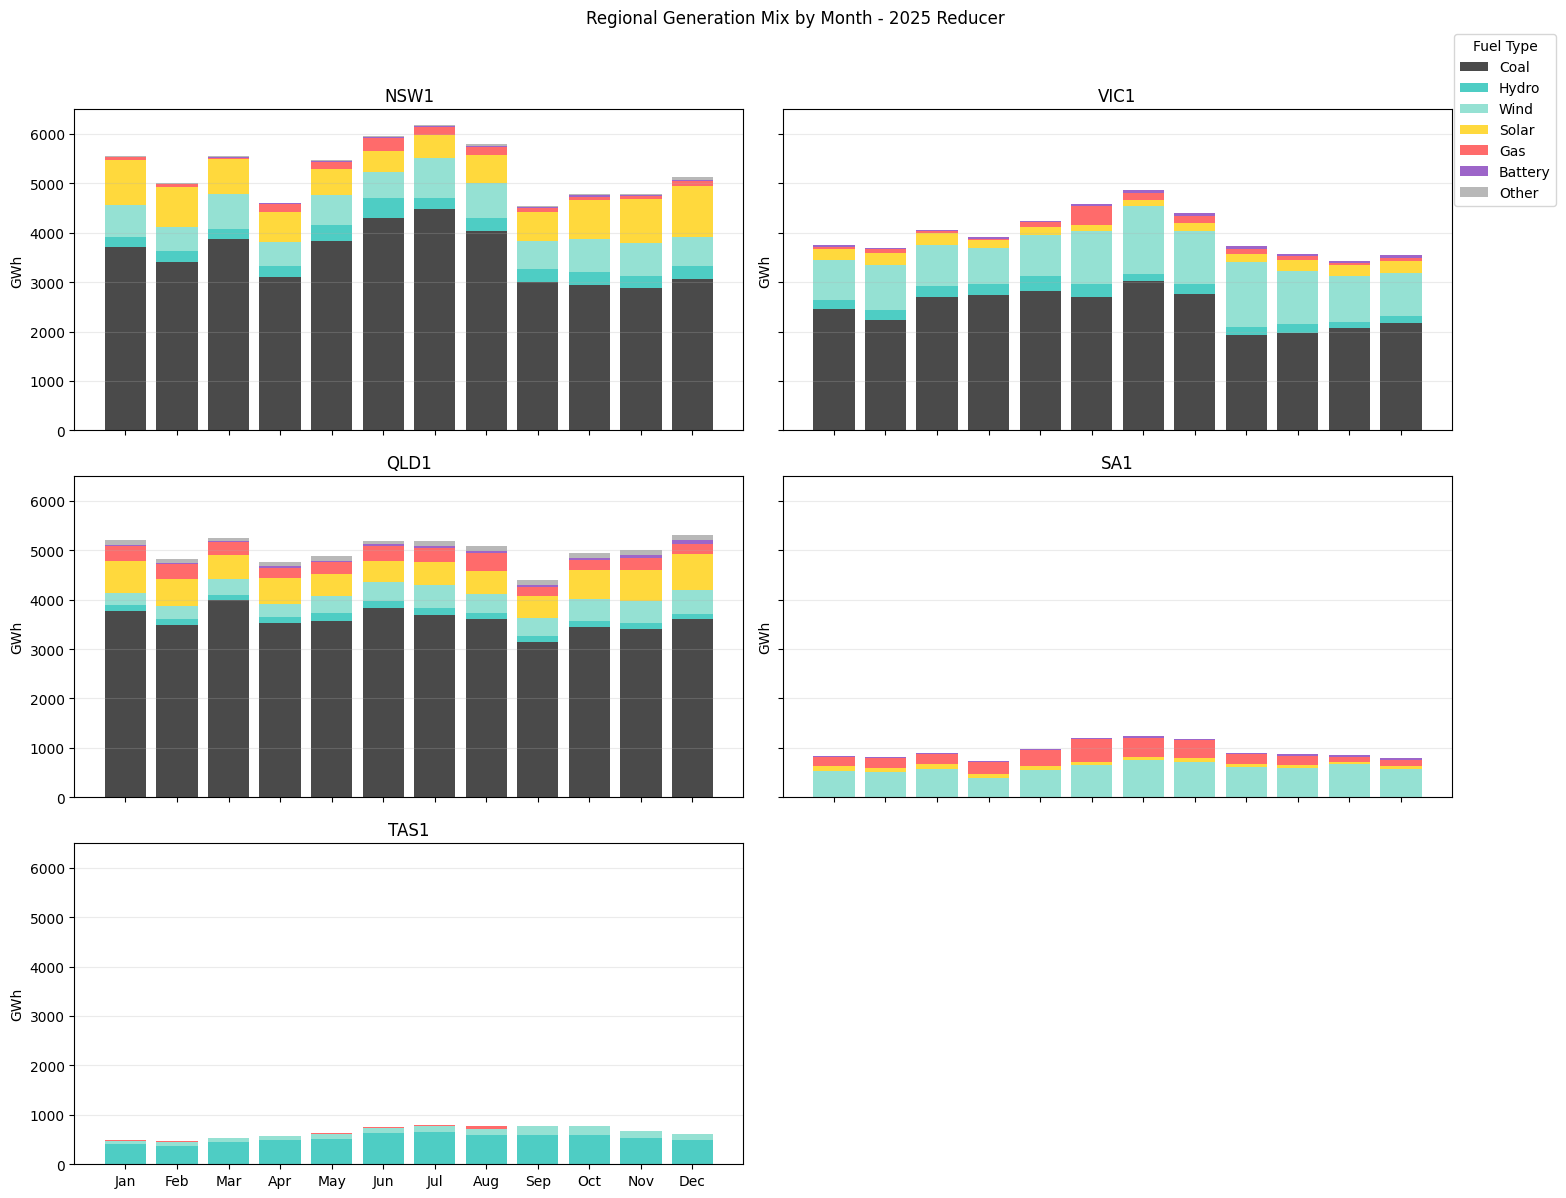

In [25]:
# Regional fuel mix by month
fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

for idx, region in enumerate(region_order):
    ax = axes[idx]
    region_month = (
        region_fuel_month
        .filter(pl.col('REGIONID') == region)
        .pivot(index='MONTH_NUM', on='FUEL_TYPE', values='GEN_MWH_MONTH', aggregate_function='sum')
        .sort('MONTH_NUM')
        .fill_null(0)
    )

    if len(region_month) == 0:
        ax.set_visible(False)
        continue

    fuels = present_stack_fuels(region_month)
    months = region_month['MONTH_NUM'].to_numpy()
    bottom = np.zeros(len(months))

    for fuel in fuels:
        values = region_month[fuel].to_numpy() / 1000
        ax.bar(months, values, bottom=bottom, color=stack_colors[fuel], width=0.8, label=fuel)
        bottom += values

    ax.set_title(region)
    ax.set_xticks(months)
    ax.set_xticklabels([month_labels[m - 1] for m in months], rotation=0)
    ax.set_ylabel('GWh')
    ax.grid(alpha=0.25, axis='y')

axes[-1].axis('off')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Fuel Type', bbox_to_anchor=(0.98, 0.98), loc='upper right')
fig.suptitle('Regional Generation Mix by Month - 2025 Reducer', y=0.995)
plt.tight_layout(rect=[0, 0, 0.92, 0.97])
plt.show()


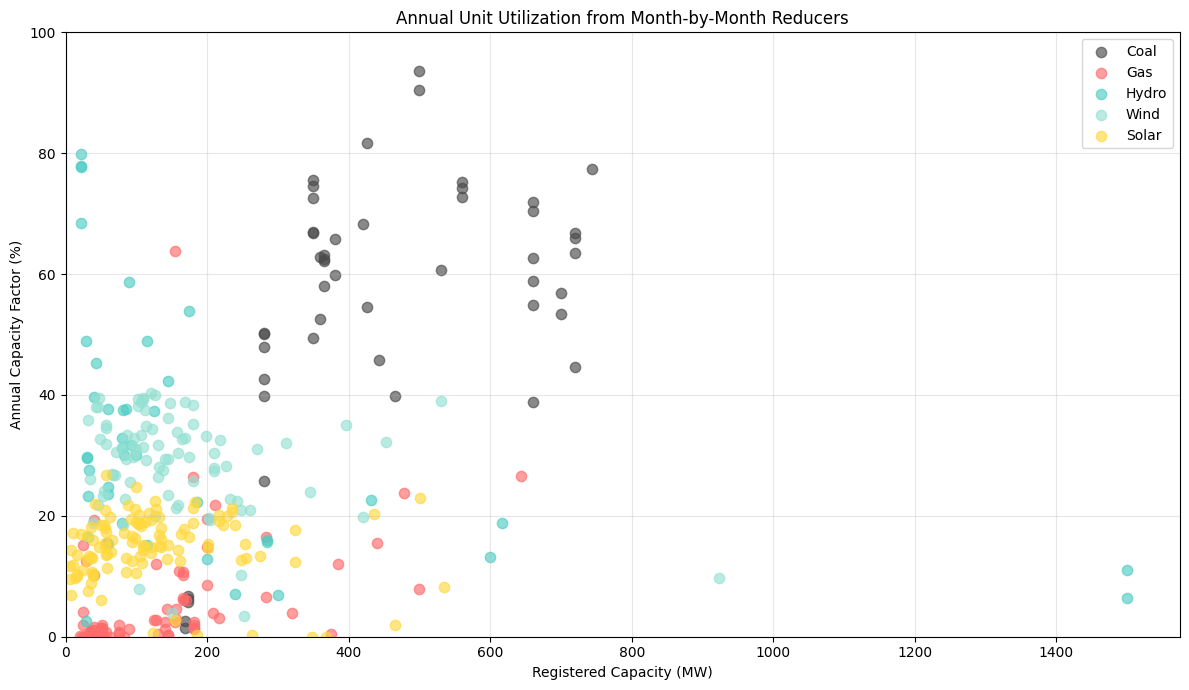

In [26]:
# Annual unit utilization scatter
fig, ax = plt.subplots(figsize=(12, 7))

for fuel in ['Coal', 'Gas', 'Hydro', 'Wind', 'Solar', 'Biomass']:
    subset = annual_unit.filter((pl.col('FUEL_TYPE') == fuel) & (pl.col('GEN_MWH_ANNUAL') > 0))
    if len(subset) == 0:
        continue

    ax.scatter(
        subset['REG_CAPACITY'].to_numpy(),
        subset['CF_ANNUAL'].to_numpy() * 100,
        label=fuel,
        color=stack_colors.get(fuel, '#B8B8B8'),
        alpha=0.65,
        s=55,
    )

ax.set_xlabel('Registered Capacity (MW)')
ax.set_ylabel('Annual Capacity Factor (%)')
ax.set_title('Annual Unit Utilization from Month-by-Month Reducers')
ax.set_xlim(0, None)
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


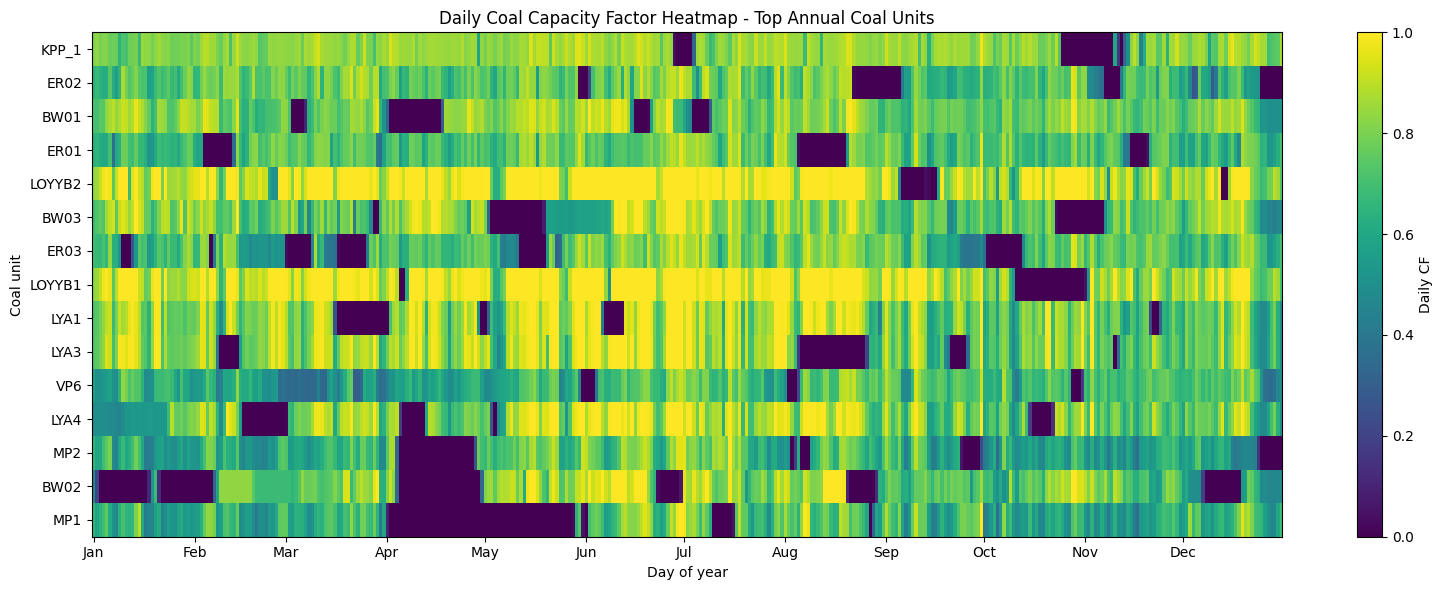

In [27]:
# Coal low-output / outage heatmap
coal_leaders = (
    annual_unit
    .filter(pl.col('FUEL_TYPE') == 'Coal')
    .sort('GEN_MWH_ANNUAL', descending=True)
    .head(15)
)

coal_duids = coal_leaders['DUID'].to_list()
all_days = unit_day.select('DAY').unique().sort('DAY')['DAY'].to_list()
coal_matrix = np.zeros((len(coal_duids), len(all_days)))

for row_idx, duid in enumerate(coal_duids):
    series = (
        unit_day
        .filter(pl.col('DUID') == duid)
        .select(['DAY', 'CF_DAY'])
        .sort('DAY')
    )
    value_map = dict(zip(series['DAY'].to_list(), series['CF_DAY'].fill_null(0).to_list()))
    for col_idx, day in enumerate(all_days):
        coal_matrix[row_idx, col_idx] = value_map.get(day, 0.0)

month_tick_positions = [idx for idx, day in enumerate(all_days) if getattr(day, 'day', None) == 1]
month_tick_labels = [month_labels[all_days[idx].month - 1] for idx in month_tick_positions]

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(coal_matrix, aspect='auto', cmap='viridis', vmin=0, vmax=1)
ax.set_yticks(range(len(coal_duids)))
ax.set_yticklabels(coal_duids)
ax.set_xticks(month_tick_positions)
ax.set_xticklabels(month_tick_labels, rotation=0)
ax.set_xlabel('Day of year')
ax.set_ylabel('Coal unit')
ax.set_title('Daily Coal Capacity Factor Heatmap - Top Annual Coal Units')
fig.colorbar(im, ax=ax, label='Daily CF')
plt.tight_layout()
plt.show()


Top 20 generators by annual generation:
shape: (20, 7)
┌────────┬──────────────────────┬───────────┬──────────┬──────────────┬────────────────┬───────────┐
│ DUID   ┆ STATIONNAME          ┆ FUEL_TYPE ┆ REGIONID ┆ REG_CAPACITY ┆ GEN_GWH_ANNUAL ┆ CF_ANNUAL │
│ ---    ┆ ---                  ┆ ---       ┆ ---      ┆ ---          ┆ ---            ┆ ---       │
│ str    ┆ str                  ┆ str       ┆ str      ┆ f64          ┆ f64            ┆ f64       │
╞════════╪══════════════════════╪═══════════╪══════════╪══════════════╪════════════════╪═══════════╡
│ KPP_1  ┆ Kogan Creek Power    ┆ Coal      ┆ QLD1     ┆ 744.0        ┆ 5048.723481    ┆ 0.774648  │
│        ┆ Station              ┆           ┆          ┆              ┆                ┆           │
│ ER02   ┆ Eraring Power        ┆ Coal      ┆ NSW1     ┆ 720.0        ┆ 4211.948432    ┆ 0.6678    │
│        ┆ Station              ┆           ┆          ┆              ┆                ┆           │
│ BW01   ┆ Bayswater Power      ┆ Co

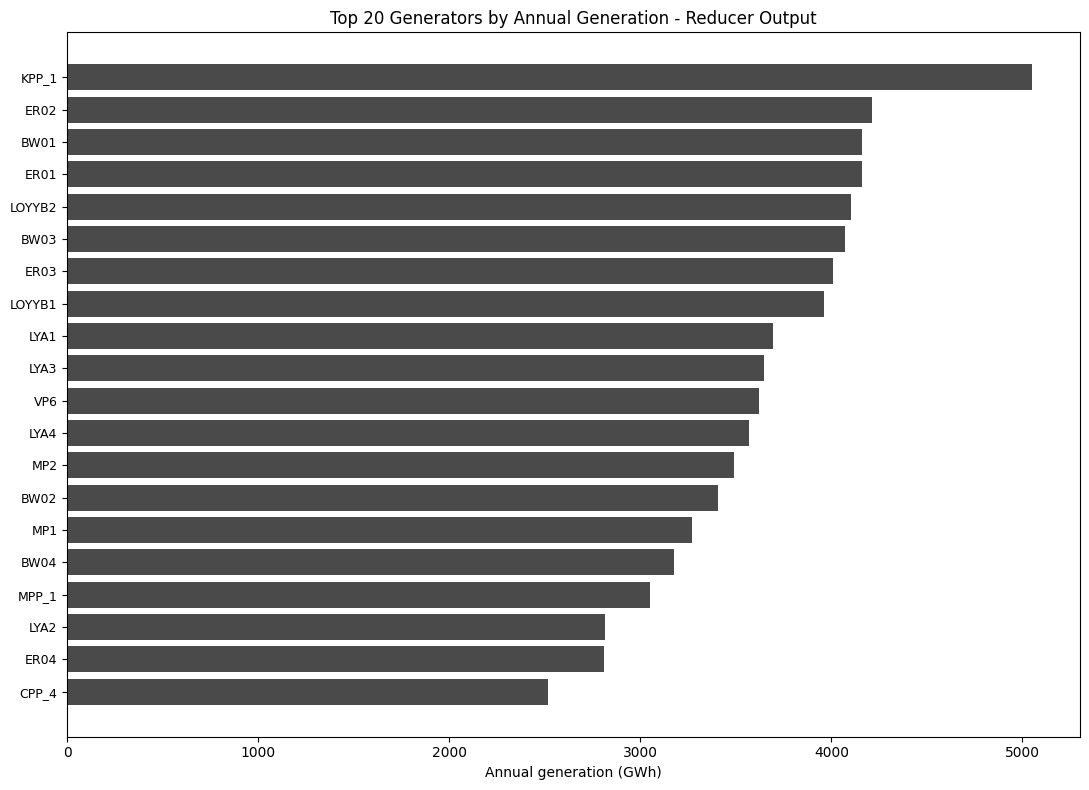

In [28]:
# Top generators by annual generation
top_20 = (
    annual_unit
    .head(20)
    .with_columns((pl.col('GEN_MWH_ANNUAL') / 1000).alias('GEN_GWH_ANNUAL'))
)

print('Top 20 generators by annual generation:')
print(top_20.select(['DUID', 'STATIONNAME', 'FUEL_TYPE', 'REGIONID', 'REG_CAPACITY', 'GEN_GWH_ANNUAL', 'CF_ANNUAL']))

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(
    range(len(top_20)),
    top_20['GEN_GWH_ANNUAL'].to_numpy(),
    color=[stack_colors.get(fuel, '#B8B8B8') for fuel in top_20['FUEL_TYPE'].to_list()],
)
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['DUID'].to_list(), fontsize=9)
ax.set_xlabel('Annual generation (GWh)')
ax.set_title('Top 20 Generators by Annual Generation - Reducer Output')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## Notes

This prototype keeps the annual analysis memory-bounded by reducing each month immediately.

If these reducer outputs prove more stable and informative than the sampled-week approach, the main Notebook 1.2 can be rearchitected so that:
- representative-week visuals stay as the high-resolution intuition layer
- annual CF, regional mix, outage screening, and top-generator rankings come from full-year monthly reducers instead of sampled weeks
